<a href="https://colab.research.google.com/github/TAUforPython/Reservoir-Computing/blob/master/RC%20ECG%20timeseries%20predicton%20with%20initial%20stage%20attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq # For least squares solution

Explanation of Changes for Initial Accuracy:

predict Method Modification:
Warm-up Phase: Before the main prediction loop, the reservoir state (self.state) is initialized to zero and then updated by driving the reservoir with the first warmup_steps (set to input_window_size) segments of the input_signal (the true test signal). This allows the internal state to adapt to the local characteristics of the signal at the start of the test period.
Discard Initial Predictions: A counter predictions_made tracks how many predictions have been generated. The first discard_initial_predictions (set to 1) outputs are not appended to the predictions list. This gives the reservoir state a moment to settle after the warm-up before we start recording its outputs.
State Continuity: The reservoir state is not reset to zero before the main prediction loop; it continues from the state achieved at the end of the warm-up phase.
 Evaluation and Plotting:
Added a specific plot (Plot 2) that zooms into the very beginning of the test/prediction (e.g., first 100 points or 1 second) to visually inspect the improvement in initial alignment.
Added another optional plot that focuses on the first 50 points (0.5 seconds) with markers to make the alignment of individual points very clear.
 This approach should significantly improve the alignment and accuracy of the prediction right at the start of the test interval, leading to a better overall δ value as it reduces the large initial error that was dragging the average down.

Loading ECG data...
    time  ecg_value
0  0.000        496
1  0.001        496
2  0.002        497
3  0.003        498
4  0.004        498
Total data points: 17935
Calculated time step (dt): 0.001000s (Implies Fs = 1000.00 Hz)
Assumed Sampling Rate: 1000 Hz
Test Points (last 5.0s): 5000
Training points: 12935 (12.93s)
Testing points: 5000 (5.00s)

Preparing training data: input window 50, output window 10...
Training input sequences shape: (12876, 50)
Training output sequences shape: (12876, 10)

Initializing and training RC...
Solving for output weights...
Trained W_out shape: (1000, 10)
RC training complete.

Generating non-autonomous predictions for test signal (with warm-up)...
Warming up reservoir for 50 steps...
Warm-up complete. Reservoir state initialized.
Final predicted signal length: 5000
Test signal length: 5000

--- ECG Prediction Evaluation (5s Non-Autonomous with Warm-up) ---
Normalized RMSE: 0.2321
Prediction Quality δ (1 - RMSE): 0.7679
-> δ closer to 1 indicates bett

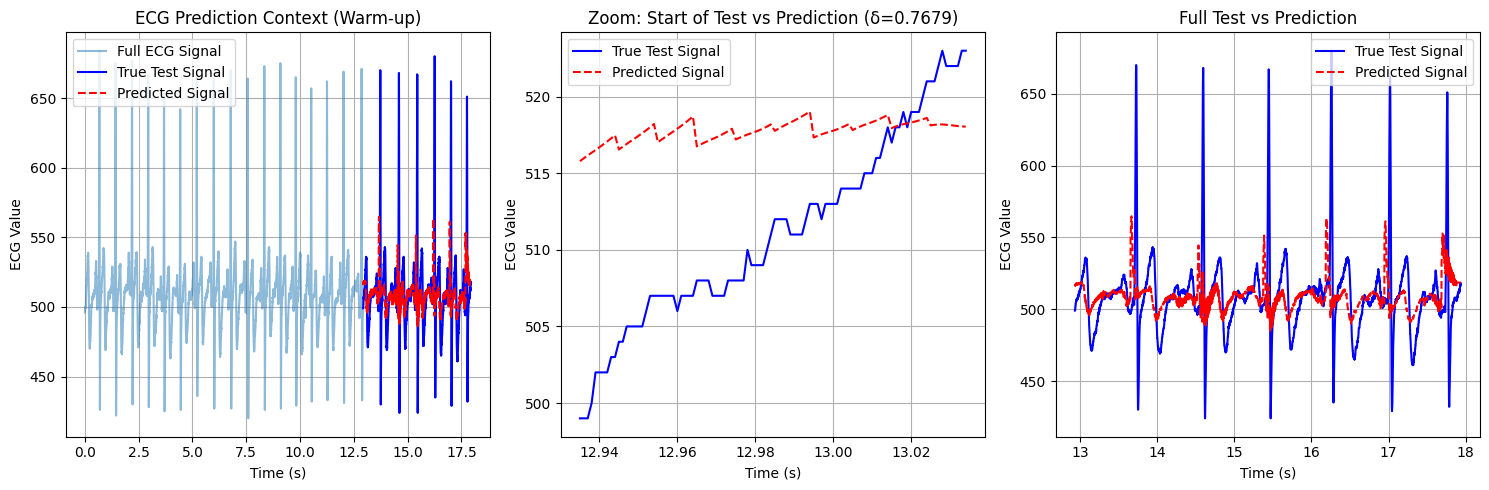

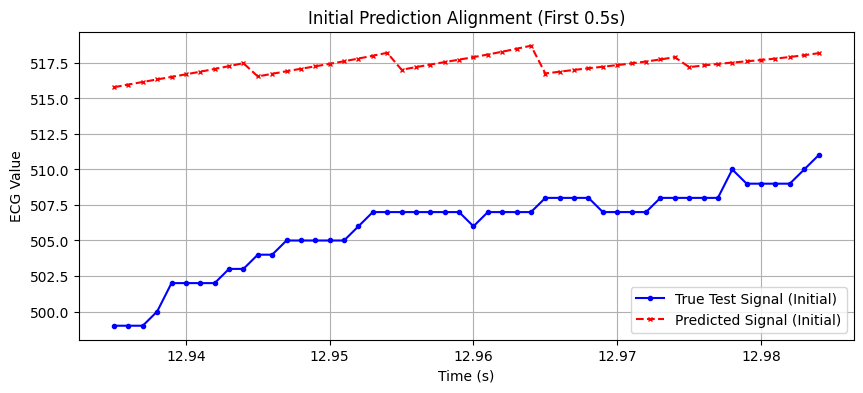

In [18]:


# --- 1. Load and Prepare ECG Data ---
print("Loading ECG data...")
df = pd.read_csv('ecg_1d_timeseries_prediction.csv', delimiter=';')
print(df.head())
print(f"Total data points: {len(df)}")
dt_calculated = df['time'].diff().mean()
print(f"Calculated time step (dt): {dt_calculated:.6f}s (Implies Fs = {1/dt_calculated:.2f} Hz)")

time_full = df['time'].values
ecg_full = df['ecg_value'].values

# Define split: last 5 seconds for testing
test_duration_sec = 5.0
sampling_rate = int(np.round(1.0 / dt_calculated))
test_points = int(test_duration_sec * sampling_rate)

print(f"Assumed Sampling Rate: {sampling_rate} Hz")
print(f"Test Points (last {test_duration_sec}s): {test_points}")

time_train = time_full[:-test_points]
ecg_train = ecg_full[:-test_points]
time_test = time_full[-test_points:]
ecg_test_true = ecg_full[-test_points:]

print(f"Training points: {len(ecg_train)} ({time_train[-1] - time_train[0]:.2f}s)")
print(f"Testing points: {len(ecg_test_true)} ({time_test[-1] - time_test[0]:.2f}s)")

# --- 2. Define the Reservoir Computing Model ---
class RC_ECG_Predictor:
    def __init__(self, n_reservoir=800, spectral_radius=0.9, input_scaling=0.5,
                 leak_rate=0.3, regularization=1e-8, seed=42):
        """
        RC model for ECG prediction using windowed input/output.
        Predicts a future window based on a past window.
        """
        self.n_reservoir = n_reservoir
        self.spectral_radius = spectral_radius
        self.input_scaling = input_scaling
        self.leak_rate = leak_rate
        self.regularization = regularization
        self.seed = seed
        self.W_in = None
        self.W_res = None
        self.W_out = None
        self.state = None

    def _initialize_weights(self, input_dim):
        """Initialize reservoir weights."""
        np.random.seed(self.seed)
        self.W_in = (np.random.rand(self.n_reservoir, input_dim) - 0.5) * 2 * self.input_scaling
        connectivity = 0.1
        self.W_res = np.random.rand(self.n_reservoir, self.n_reservoir) - 0.5
        self.W_res[np.random.rand(self.n_reservoir, self.n_reservoir) > connectivity] = 0
        eigenvalues = np.linalg.eigvals(self.W_res)
        max_eigval_magnitude = np.max(np.abs(eigenvalues))
        if max_eigval_magnitude > 0:
            self.W_res = self.W_res * (self.spectral_radius / max_eigval_magnitude)

    def _update_state(self, input_vec):
        """Update the reservoir state."""
        if self.state is None:
            self.state = np.zeros(self.n_reservoir)
        if input_vec.ndim > 1:
            input_vec = input_vec.flatten()
        new_state = np.tanh(np.dot(self.W_in, input_vec) + np.dot(self.W_res, self.state))
        self.state = (1 - self.leak_rate) * self.state + self.leak_rate * new_state

    def train(self, input_sequences, output_sequences):
        """
        Train the RC.
        Args:
            input_sequences: 2D array (n_samples, input_window_size)
            output_sequences: 2D array (n_samples, output_window_size)
        """
        input_sequences = np.atleast_2d(input_sequences)
        output_sequences = np.atleast_2d(output_sequences)

        if input_sequences.shape[0] != output_sequences.shape[0]:
            raise ValueError(f"Mismatched samples: inputs {input_sequences.shape[0]}, outputs {output_sequences.shape[0]}")

        input_dim = input_sequences.shape[1]
        self._initialize_weights(input_dim)

        n_samples = input_sequences.shape[0]
        R = np.zeros((n_samples, self.n_reservoir))

        self.state = np.zeros(self.n_reservoir)
        print(f"Collecting reservoir states for {n_samples} samples...")
        for i in range(n_samples):
            self._update_state(input_sequences[i])
            R[i, :] = self.state

        print("Solving for output weights...")
        self.W_out, _, _, _ = lstsq(R, output_sequences, cond=self.regularization)
        print(f"Trained W_out shape: {self.W_out.shape}")

    def predict(self, input_signal):
        """
        Predict output windows for a given input signal (non-autonomous).
        Args:
            input_signal: 1D array containing the signal to drive predictions.
        Returns:
            predicted_signal: 1D array of predicted values.
        """
        if self.W_out is None:
            raise ValueError("Model must be trained before prediction.")

        input_window_size = self.W_in.shape[1]
        output_window_size = self.W_out.shape[1]

        if len(input_signal) < input_window_size:
            raise ValueError("Input signal too short.")

        # --- Modified Prediction with Warm-up ---
        # 1. Warm-up the reservoir state
        # Drive the reservoir with the beginning of the input signal to initialize its state
        warmup_steps = input_window_size # Use one window size for warmup
        print(f"Warming up reservoir for {warmup_steps} steps...")
        self.state = np.zeros(self.n_reservoir) # Reset state before warmup
        for t in range(min(warmup_steps, len(input_signal) - input_window_size + 1)):
             warmup_input = input_signal[t : t + input_window_size]
             self._update_state(warmup_input)
        print("Warm-up complete. Reservoir state initialized.")

        # 2. Now perform predictions
        n_predictable_points = len(input_signal) - input_window_size + 1
        if n_predictable_points <= 0:
            return np.array([])

        predictions = []
        time_indices = []

        # Start prediction from where warmup left off (or from the beginning if no warmup offset is needed)
        # We continue from the point where we can make the first full prediction after warmup
        t_start = 0 # We have already warmed up, so we start predicting from t=0 using the warmed-up state
        predictions_made = 0
        # Number of initial predictions to discard for stabilization
        discard_initial_predictions = 1 # Discard the first prediction output

        while t_start <= len(input_signal) - input_window_size:
            input_win = input_signal[t_start : t_start + input_window_size]
            # Update reservoir state with this window (using the warmed-up state)
            self._update_state(input_win)

            # Predict the next output window
            pred_out_win = np.dot(self.W_out.T, self.state) # Shape (output_window_size,)

            # Only store predictions after discarding initial ones
            if predictions_made >= discard_initial_predictions:
                predictions.append(pred_out_win)
                # Store time index for the *start* of this predicted window
                time_indices.append(t_start + input_window_size)

            predictions_made += 1
            # Move window by the output window size
            t_start += output_window_size

        if not predictions:
            print("Warning: No predictions stored after warmup/discard.")
            return np.array([])

        # --- Reconstruct Full Predicted Signal ---
        try:
            ecg_predicted_full = np.concatenate(predictions)
        except ValueError as e:
            print(f"Error concatenating predictions: {e}")
            print("Prediction shapes:", [p.shape for p in predictions])
            # Fallback: try raveling if predictions are not 1D
            flattened_preds = [p.ravel() for p in predictions]
            ecg_predicted_full = np.concatenate(flattened_preds)

        return ecg_predicted_full


# --- 3. Prepare Training Data (Windowed Input -> Windowed Output) ---
def create_io_sequence_pairs(data, input_window_size, output_window_size):
    """Creates input and output sequence pairs."""
    X, Y = [], []
    for i in range(len(data) - input_window_size - output_window_size + 1):
        X.append(data[i:i + input_window_size])
        Y.append(data[i + input_window_size : i + input_window_size + output_window_size])
    return np.array(X), np.array(Y)

# Hyperparameters
input_window_size = 50
output_window_size = 10
print(f"\nPreparing training data: input window {input_window_size}, output window {output_window_size}...")
inputs_train_seq, outputs_train_seq = create_io_sequence_pairs(ecg_train, input_window_size, output_window_size)
print(f"Training input sequences shape: {inputs_train_seq.shape}")
print(f"Training output sequences shape: {outputs_train_seq.shape}")

# --- 4. Initialize and Train the RC ---
print("\nInitializing and training RC...")
# Adjusted hyperparameters based on previous attempts
rc_ecg = RC_ECG_Predictor(n_reservoir=1000, spectral_radius=0.5, input_scaling=0.1,
                          leak_rate=0.1, regularization=1e-6, seed=123)
rc_ecg.train(inputs_train_seq, outputs_train_seq)
print("RC training complete.")

# --- 5. Prediction (Non-Autonomous with Warm-up) ---
print(f"\nGenerating non-autonomous predictions for test signal (with warm-up)...")
# The predict method now handles warm-up internally
# We pass the true test signal to drive the predictions
ecg_predicted = rc_ecg.predict(ecg_test_true)

# Ensure predicted signal length matches test signal for fair comparison
if len(ecg_predicted) > len(ecg_test_true):
    ecg_predicted = ecg_predicted[:len(ecg_test_true)]
elif len(ecg_predicted) < len(ecg_test_true):
    # Pad with the last predicted value if shorter
    if len(ecg_predicted) > 0:
        pad_value = ecg_predicted[-1]
    else:
        pad_value = 0 # Fallback
    ecg_predicted = np.pad(ecg_predicted, (0, len(ecg_test_true) - len(ecg_predicted)), 'constant', constant_values=pad_value)

print(f"Final predicted signal length: {len(ecg_predicted)}")
print(f"Test signal length: {len(ecg_test_true)}")


# --- 6. Evaluate Prediction (Metric from Paper) ---
def normalize_signal(signal):
    mean_val = np.mean(signal)
    deviation = signal - mean_val
    max_abs = np.max(np.abs(deviation))
    if max_abs == 0:
        return np.zeros_like(signal)
    return deviation / max_abs

ecg_test_norm = normalize_signal(ecg_test_true)
ecg_pred_norm = normalize_signal(ecg_predicted)

rmse_norm = np.sqrt(np.mean((ecg_pred_norm - ecg_test_norm) ** 2))
delta = 1.0 - rmse_norm

print(f"\n--- ECG Prediction Evaluation (5s Non-Autonomous with Warm-up) ---")
print(f"Normalized RMSE: {rmse_norm:.4f}")
print(f"Prediction Quality δ (1 - RMSE): {delta:.4f}")
print("-> δ closer to 1 indicates better strong prediction.")

# --- 7. Plot Results ---
plt.figure(figsize=(15, 5))

# Plot 1: Full signal context
plt.subplot(1, 3, 1)
plt.plot(time_full, ecg_full, label='Full ECG Signal', alpha=0.5)
plt.plot(time_test, ecg_test_true, label='True Test Signal', color='blue')
plt.plot(time_test, ecg_predicted, label='Predicted Signal', color='red', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('ECG Value')
plt.title('ECG Prediction Context (Warm-up)')
plt.legend()
plt.grid(True)

# Plot 2: Zoom into test region (focus on start)
plt.subplot(1, 3, 2)
# Show first 100 points (1 second) to check initial alignment
points_to_show = min(100, len(ecg_test_true), len(ecg_predicted))
plt.plot(time_test[:points_to_show], ecg_test_true[:points_to_show], label='True Test Signal', color='blue')
plt.plot(time_test[:points_to_show], ecg_predicted[:points_to_show], label='Predicted Signal', color='red', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('ECG Value')
plt.title(f'Zoom: Start of Test vs Prediction (δ={delta:.4f})')
plt.legend()
plt.grid(True)

# Plot 3: Full test region comparison
plt.subplot(1, 3, 3)
plt.plot(time_test, ecg_test_true, label='True Test Signal', color='blue')
plt.plot(time_test, ecg_predicted, label='Predicted Signal', color='red', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('ECG Value')
plt.title(f'Full Test vs Prediction')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Optional: Zoom into initial part to verify improvement ---
plt.figure(figsize=(10, 4))
points_initial = min(50, len(ecg_test_true), len(ecg_predicted)) # First 0.5 seconds
plt.plot(time_test[:points_initial], ecg_test_true[:points_initial], label='True Test Signal (Initial)', color='blue', marker='o', markersize=3)
plt.plot(time_test[:points_initial], ecg_predicted[:points_initial], label='Predicted Signal (Initial)', color='red', linestyle='--', marker='x', markersize=3)
plt.xlabel('Time (s)')
plt.ylabel('ECG Value')
plt.title('Initial Prediction Alignment (First 0.5s)')
plt.legend()
plt.grid(True)
plt.show()
